Импорт необходимых модулей:

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import numpy as np
from PIL import Image 

# from math import isqrt

### Генерируем точки + строим графики и изображения

In [60]:
total_points_sqrt = 3163
total_points = total_points_sqrt * total_points_sqrt

print(total_points)

10004569


Запускаем сценарий сборки

In [61]:
os.system("make")

0

Запускаем генерацию точек

In [62]:
os.system("release/executable --xs64 " + str(total_points) + " 0 1")
os.system("release/executable --xs1024 " + str(total_points) + " 0 1")
os.system("release/executable --mt19937 " + str(total_points) + " 0 1")

Elapsed time for generator: "xor-shift-64" --- 3457871 microseconds
Elapsed time for generator: "xor-shift-1024" --- 3460179 microseconds
Elapsed time for generator: "mt19937" --- 3499741 microseconds


0

Подгружаем сгенерированные выборки:

In [63]:
x64      = pd.read_csv("xor_shift_64__sample.csv")
x1024    = pd.read_csv("xor_shift_1024__sample.csv")
mt19937  = pd.read_csv("mt19937__sample.csv")

Вывод первых 5-ти значий со сгенерированного файла:

In [64]:
x64.head()

,randoms
0,0.205570
1,0.486934
2,0.650881
3,0.221048
4,0.767334


Описательная статистика:

In [65]:
x64['randoms'].describe()

count    1.000457e+07
mean     5.000783e-01
std      2.887118e-01
min      6.337890e-08
25%      2.500270e-01
50%      5.001590e-01
75%      7.501520e-01
max      1.000000e+00
Name: randoms, dtype: float64

Строим гистограммы:

(9500.0, 10550.0)

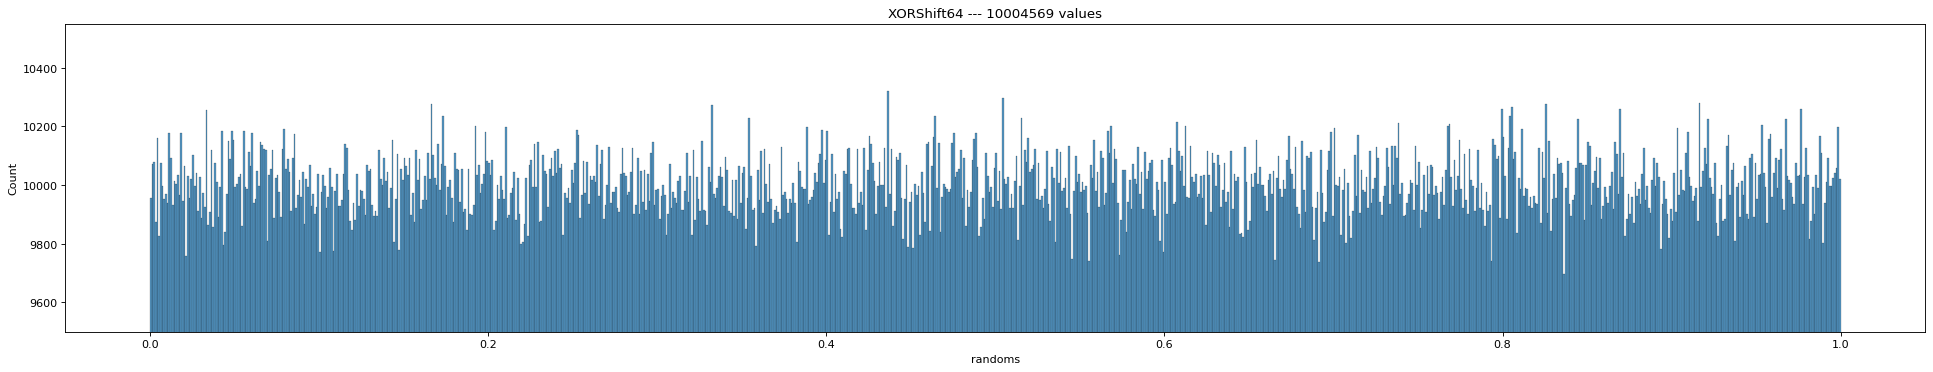

In [66]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x64, x="randoms", bins=1000).set(title='XORShift64 --- ' + str(total_points) + ' values')
plt.ylim(bottom=9500, top=10550)

In [67]:
data = 255 * np.array(x64)
data = np.uint8(data)

In [68]:
data.shape

(10004569, 1)

In [69]:
data = data.reshape(total_points_sqrt, total_points_sqrt)
print(data)

[[ 52 124 165 ... 100  33  92]
 [102  43 236 ... 212  82 245]
 [254 130  35 ... 180  62 211]
 ...
 [120   8  58 ...  80 251 222]
 [114 220  29 ...  83 135 216]
 [186   5 216 ...  93 176 182]]


In [70]:
data.shape

(3163, 3163)

In [71]:
img = Image.fromarray(data, 'L')
img.save('XORShift64_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9500.0, 10550.0)

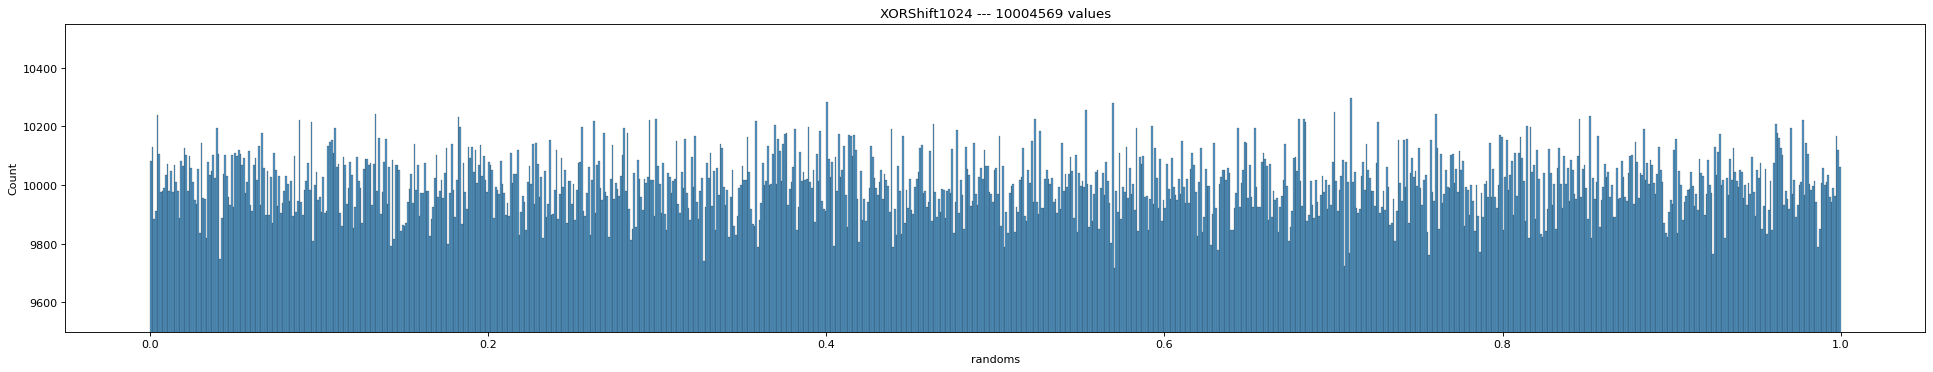

In [72]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x1024, x="randoms", bins=1000).set(title='XORShift1024 --- ' + str(total_points) + ' values')
plt.ylim(bottom=9500, top=10550)

In [73]:
data = 255 * np.array(x1024)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [74]:
img = Image.fromarray(data, 'L')
img.save('XORShift1024_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9500.0, 10550.0)

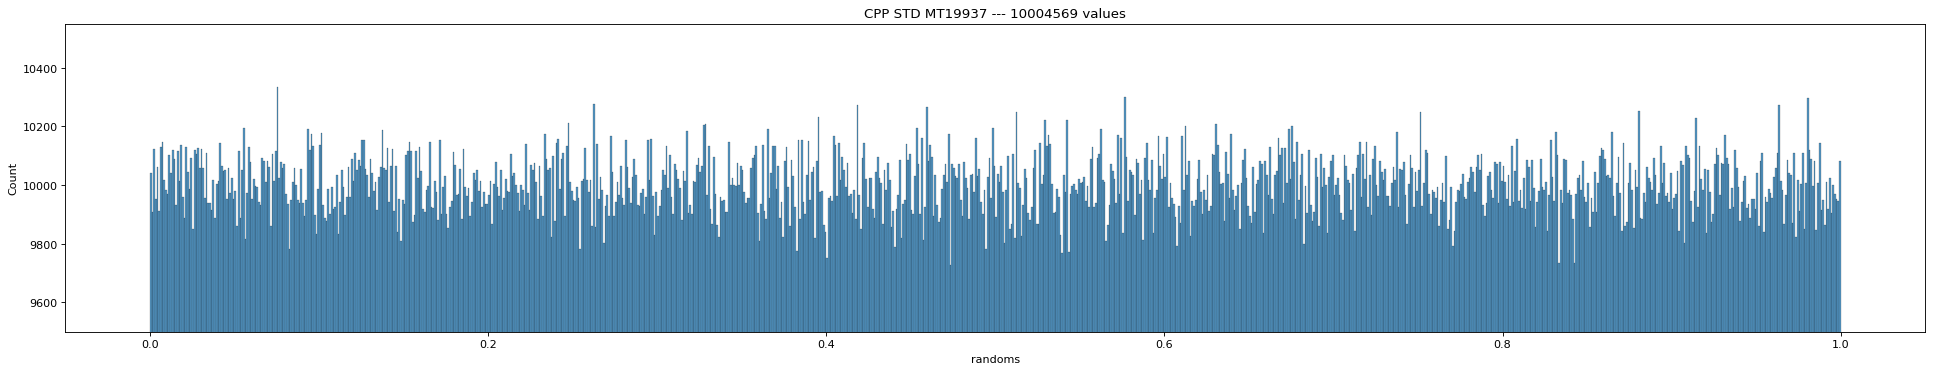

In [75]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=mt19937, x="randoms", bins=1000).set(title='CPP STD MT19937 --- ' + str(total_points) + ' values')
plt.ylim(bottom=9500, top=10550)

In [76]:
data = 255 * np.array(mt19937)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [77]:
img = Image.fromarray(data, 'L')
img.save('MT19937_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)